#### Ocean Bottom Pressure: Computing GRACE(-FO) averages and associated uncertainties from the JPL-Mascon data using gridded mask
written by: Felix Landerer (landerer@jpl.nasa.gov) and Munish Sikka (munish.sikka@jpl.nasa.gov)

Version 1.0 [May-2026]

In [1]:
import sys
import os
if 'google.colab' in sys.modules:
    print("Running in Colab. Preparing NASA-GRACE/GRACE-Analysis-Tutorials environment...")
    
    # 1. Install system libraries quietly
    !apt-get install -y libgdal-dev libproj-dev proj-data proj-bin libgeos-dev > /dev/null 2>&1
    
    # 2. Install Python packages while pinning fsspec to keep Colab happy
    # This prevents the red error message
    !pip install -q \
        fsspec==2025.3.0 \
        cartopy \
        geopandas \
        netcdf4 \
        h5netcdf \
        statsmodels \
        s3fs
    
    # 3. Clone the repository
    !git clone https://github.com/NASA-GRACE/GRACE-Analysis-Tutorials.git
    
    # 4. Move into the repo directory so Python can see your .py files
    os.chdir('/content/GRACE-Analysis-Tutorials')
    
    # 5. Add the current directory to the system path as a backup
    sys.path.append('/content/GRACE-Analysis-Tutorials')
    print("Setup complete! The environment is stable and ready.")
else:
    print("Running locally.")

Running locally.


In [2]:
import time
from netCDF4 import Dataset, date2index , num2date
from datetime import datetime, date

import xarray as xr
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt
from matplotlib.path import Path
import warnings
import os

import sys
import os.path
import subprocess
import netCDF4
import math
import csv

#import s3fs
import copy
import json, copy
from pandas import DataFrame
from osgeo import gdal, ogr, osr
import re
import calendar
from dateutil import parser
import urllib
import grace_user_functions as grace_func
import header_text
import trend_fit as fit_py

Step 1: Load GRACE/GRACE-FO data and basin masks
1.1 Read a basin mask from netcdf file

In [3]:
file_access_type = 'local'
#file_access_type = 'cloud'
ShortName_mass = 'TELLUS_GRAC-GRFO_MASCON_CRI_GRID_RL06.1_V3' # PO.DAAC's 'short name' is an identifier for the dataset
grace_filename ='GRCTellus.JPL.200204_202510.GLO.RL06.3M.MSCNv04CRI.nc' #edit to the filename user wants to read

start_date = "2002-04-01"
end_date = "none" #yyyy-mm-dd (eg. "2024-09-30") or set as none to read from filename upto the last available month
# segment to extract end date from mascon filename
if end_date == 'none':
    date_range = re.search(r"(\d{6})_(\d{6})",grace_filename)
    if not date_range:
        raise ValueError("Date range not found in filename")
    end_date_str = date_range.group(2)
    year = int(end_date_str[:4])
    month = int(end_date_str[4:])
    day = calendar.monthrange(year,month)[1]
    end_date = datetime(year,month,day).strftime("%Y-%m-%d")
print(end_date)    

# download the GRACE mascon dataset and use the absolute path in next line where it is kept in local file system
full_filename = 'GRACE_RESOURCES/' + grace_filename
mask_filename = 'GRACE_RESOURCES/' + grace_filename

mask_datset = xr.open_dataset((mask_filename))
mask_str = 'ocean'

sig_calc = 2       # 1 = calculate standard error of model to data for trend uncertainty
                    # 2 = use only measurement/leakage error to calculate trend uncertainty
OCN_GIAerr = 0.3    # GIA error in mm/yr for ocean

if mask_str == 'ocean':
    land_mask = mask_datset["land_mask"]# for land ocean mask
    mask = abs(1-land_mask)
    GIA_error = OCN_GIAerr
else:
    print('Invalid mask string for this tutorial')

mask = mask.to_numpy()

# Specify the file path greenland_mass_200204_202407
start_date_obj = datetime.strptime(start_date,"%Y-%m-%d")
start_yearmonth = start_date_obj.strftime("%Y%m")
end_date_obj = datetime.strptime(end_date,"%Y-%m-%d")
end_yearmonth = end_date_obj.strftime("%Y%m")
output_filename = f"{mask_str}_mass_{start_yearmonth}_{end_yearmonth}.txt"

2025-10-31


1.2 Read mascon dataset

In [4]:
if file_access_type.lower() == 'local':
    print("Reading GRACE mascon dataset from local disk")
    try:
        dataset = xr.open_dataset((full_filename))
    except FileNotFoundError:
        print('Error: The file does not exist.')
elif file_access_type.lower() == "cloud":
    print("Reading GRACE mascon dataset from PODAAC Cloud")
    import s3fs
    dataset=grace_func.read_grace_dataset(ShortName_mass,grace_filename)	
else:
    print("Unknown file access type.")

Reading GRACE mascon dataset from local disk


1.3 Take a look at the dataset contents that were just loaded:

In [5]:
dataset

<xarray.Dataset> Size: 2GB
Dimensions:        (time: 250, lat: 360, lon: 720, bounds: 2)
Coordinates:
  * time           (time) datetime64[ns] 2kB 2002-04-17T12:00:00 ... 2025-10-...
  * lat            (lat) float64 3kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon            (lon) float64 6kB 0.25 0.75 1.25 1.75 ... 358.8 359.2 359.8
Dimensions without coordinates: bounds
Data variables:
    lwe_thickness  (time, lat, lon) float64 518MB ...
    uncertainty    (time, lat, lon) float64 518MB ...
    lat_bounds     (lat, bounds) float64 6kB ...
    lon_bounds     (lon, bounds) float64 12kB ...
    time_bounds    (time, bounds) datetime64[ns] 4kB ...
    land_mask      (lat, lon) float64 2MB ...
    scale_factor   (lat, lon) float64 2MB ...
    mascon_ID      (lat, lon) float64 2MB ...
    GAD            (time, lat, lon) float64 518MB ...
Attributes: (12/53)
    Conventions:                   CF-1.6, ACDD-1.3, ISO 8601
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    standard_name_vocabulary:      NetCDF Climate and Forecast (CF) Metadata ...
    title:                         JPL GRACE and GRACE-FO MASCON RL06.3Mv04 CRI
    summary:                       Monthly gravity solutions from GRACE and G...
    keywords:                      Solid Earth, Geodetics/Gravity, Gravity, l...
    ...                            ...
    C_30_substitution:             TN-14; Loomis et al., 2019, Geophys. Res. ...
    user_note_1:                   The accelerometer on the GRACE-B spacecraf...
    user_note_2:                   The accelerometer on the GRACE-D spacecraf...
    journal_reference:             Watkins, M. M., D. N. Wiese, D.-N. Yuan, C...
    CRI_filter_journal_reference:  Wiese, D. N., F. W. Landerer, and M. M. Wa...
    date_created:                  2026-01-06T12:01:45Z

1.4 Assign variables to compute water-equivalent heights:

In [6]:
lwe_thickness_subset = dataset["lwe_thickness"].sel(
    time=slice(start_date, end_date)).values
tdim, ydim, xdim = lwe_thickness_subset.shape

sig_lwe = dataset["uncertainty"].sel(
    time=slice(start_date, end_date)).values

GAD = dataset["GAD"].sel(
    time=slice(start_date, end_date)).values

#lwe_thickness_subset = lwe_thickness_subset - lwe_thickness_subset[0,:,:] # moved to after basin mean calculations for ocean

lwe_thickness_subset = lwe_thickness_subset - GAD 
lwe_thickness_subset = lwe_thickness_subset * 10.0; #convert to mm

sig_lwe = dataset["uncertainty"].sel(
    time=slice(start_date, end_date)).values
sig_lwe = sig_lwe * 10.0; #convert to mm



In [7]:
lat_vector = dataset.lat[:].copy()
lon_vector = dataset.lon[:].copy()
time_subset = dataset["time"].sel(
    time=slice(start_date, end_date)).values

1.4.1 Compute weighted area for this region_mask

In [8]:
mask,mask_A,mask_N = grace_func.drainage_basin_call(mask)

Using user defined mask: 360x720


Step 2: Calculate mean over selected region

In [9]:
# Apply mask by zeroing outside region
lwe_masked = lwe_thickness_subset * mask[None, :, :]

# Area weights only inside region
weights = mask_A[None, :, :] * mask[None, :, :]

# Weighted sum and normalization
regional_timeseries = (
    np.sum(lwe_masked * weights, axis=(1, 2)) /
    np.sum(weights, axis=(1, 2))
)

In [10]:
regional_timeseries = regional_timeseries - regional_timeseries[0]

Step 3: plot basin-mean

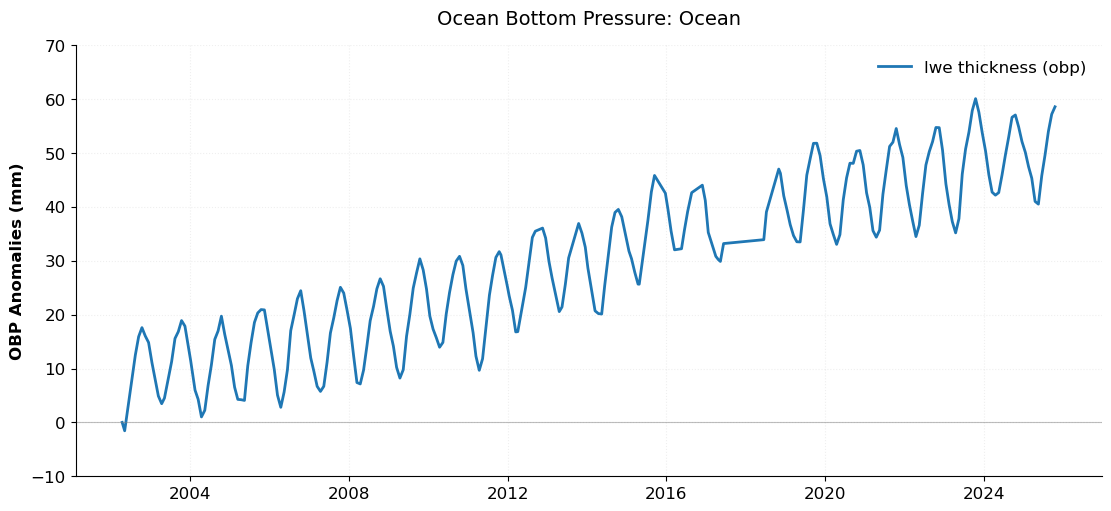

In [11]:
ymin = -10
ymax = 70
timesteps = dataset["time"].sel(
    time=slice(start_date, end_date)).values
plot_title_str = 'Ocean Bottom Pressure: ' + mask_str.capitalize()
# plot monthly timeseries (#ref: https://unidata.github.io/python-training/workshop/Time_Series/basic-time-series-plotting/)
xmin = timesteps[0]
xmax = timesteps[-1]
yticks = np.arange(ymin, ymax+1,2)

plt.rc('font', size=12)
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
# Plot the data
ax.plot(timesteps, regional_timeseries, color='tab:blue', label='lwe thickness (obp)',lw=2)
ax.axhline(y=0.0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_ylabel('OBP Anomalies (mm)', fontweight='bold')
ax.set_title(plot_title_str, fontsize=14, pad=15)
ax.set_ylim([ymin, ymax])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, linestyle=':')
ax.legend(loc='best', frameon=False)
fig.savefig(f"{mask_str}_lineplot.png",dpi=300)

In [12]:
timesteps_temp = [np.datetime64(i) for i in timesteps]
timesteps_datetime = pd.to_datetime(timesteps_temp)
date_str_list = [str(i.date()) for i in timesteps_datetime]
date_obj_list = [datetime.strptime(date_str,"%Y-%m-%d") for date_str in date_str_list]
timesteps_yearfrac = [grace_func.toYearFraction(date_obj) for date_obj in date_obj_list]

In [13]:
#read the grid of mascon IDs from the mascon dataset
mascon_ID= dataset["mascon_ID"]
mscID=mascon_ID.to_numpy()
msc_type = 'full'; 

In [14]:
mask,mask_A,mask_N = grace_func.drainage_basin_call(mask)
mask[mask>0] = 1

# rerun with binary [0,1] mask:
mask,mask_A,mask_N = grace_func.drainage_basin_call(mask)

Using user defined mask: 360x720
Using user defined mask: 360x720


In [15]:
w = np.unique(mask * mscID)
mask = np.isin(mscID,w).astype(int)

# rerun with this mask:
mask,mask_A,mask_N = grace_func.drainage_basin_call(mask)

Using user defined mask: 360x720


In [16]:
# find uncertainty values within the basin mask:
sig_lwe_ma , maA = grace_func.compute_regional_uncertainty(sig_lwe, mask_A, mscID) 

# RSS (Root Sum of Squares) for total regional error
# Divide by total area to get the area-weighted average uncertainty
#bsn_sig = (np.sqrt(np.sum(np.square(sig_lwe_ma),axis=1)))#used for greenland, antarctica icesheets
bsn_sig = (np.sqrt(np.sum(np.square(sig_lwe_ma),axis=1)))/np.sum(maA)

In [17]:
lower_bound = regional_timeseries - bsn_sig
upper_bound = regional_timeseries + bsn_sig

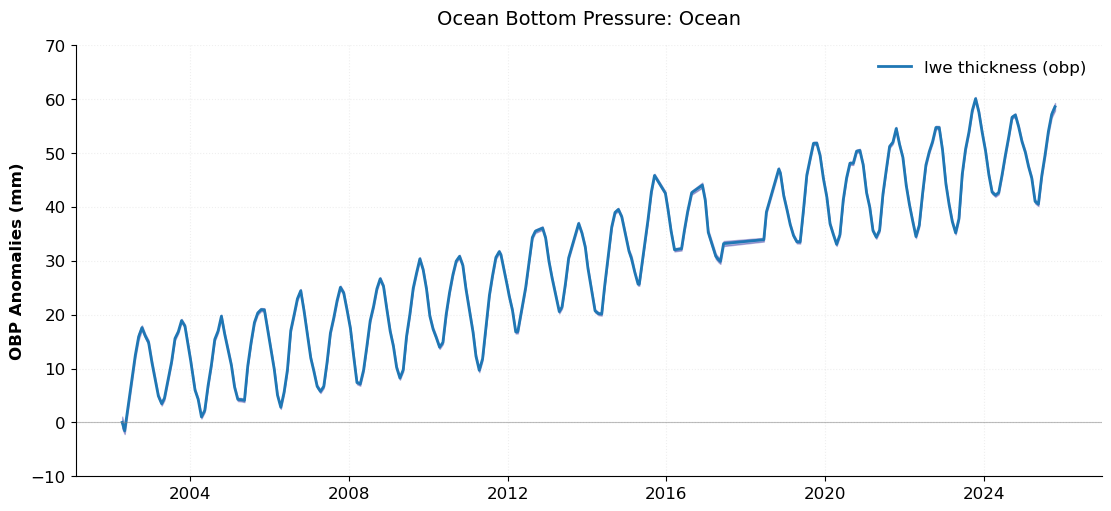

In [18]:
# plot monthly timeseries (#ref: https://unidata.github.io/python-training/workshop/Time_Series/basic-time-series-plotting/)
plt.rc('font', size=12)
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
# Specify how our lines should look
region_color='darkblue'
ax.plot(timesteps, regional_timeseries, color='tab:blue', label='lwe thickness (obp)',lw=2)
ax.fill_between(timesteps, lower_bound, upper_bound, alpha=0.3, edgecolor=region_color, facecolor=region_color)
ax.axhline(y=0.0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_ylabel('OBP Anomalies (mm)', fontweight='bold')
ax.set_title(plot_title_str, fontsize=14, pad=15)
ax.set_ylim([ymin, ymax])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, linestyle=':')
ax.legend(loc='best', frameon=False)

In [19]:
freq = [1, 2] 
poly_deg = 1 
exclude_trend = 0 # do not exclude trend here
timesteps_np = np.array(timesteps_yearfrac)
model,sds,unused = fit_py.fit_tsin(timesteps_np, regional_timeseries,sig=bsn_sig, poly_deg=poly_deg, freq=freq, offsets=[], return_amp_phase=False, return_param_unc=True, chi2_cor=True, S2_G_GFO_shift=1)

trend = np.round(model[-2],2)
stddev = np.round(abs(sds[-2]*2),2)

In [20]:
print(model)

[-8.50796052e+00  1.39843738e+00  5.48662408e-01  4.92835176e-01
  1.99272599e+00 -3.98373491e+03]


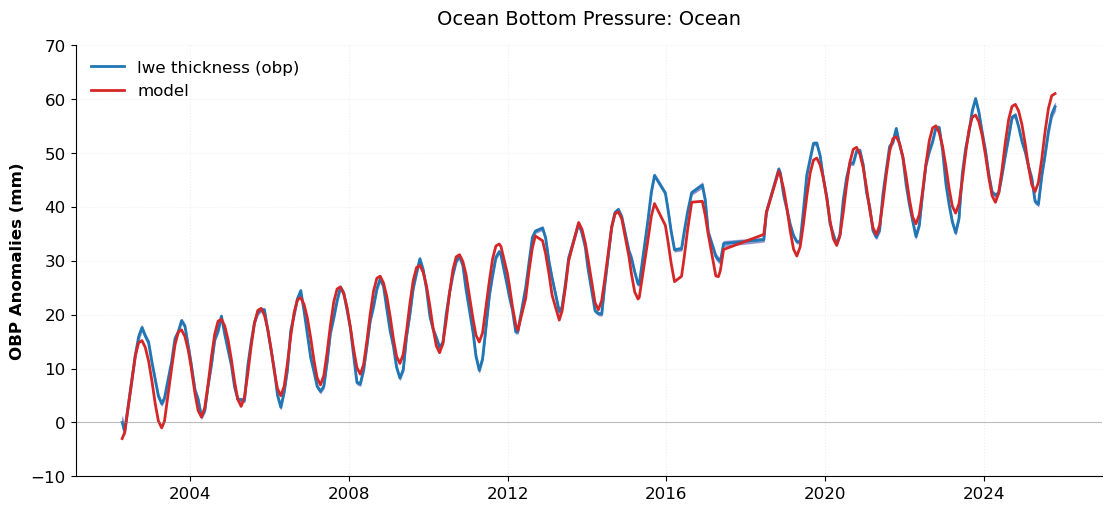

In [21]:
# create fitted timeseries and plot it along with original lwe_thickness for comparison
# exapnd the fitted model
get_model = fit_py.get_tsin(model, timesteps_np,poly_deg,exclude_trend, freq, offsets=[], is_amp_phase=False, S2_G_GFO_shift=1)
# plot monthly timeseries (#ref: https://unidata.github.io/python-training/workshop/Time_Series/basic-time-series-plotting/)
plt.rc('font', size=12)
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
# Specify how our lines should look
region_color='darkblue'
ax.plot(timesteps, regional_timeseries, color='tab:blue', label='lwe thickness (obp)',lw=2)
ax.plot(timesteps, get_model, color='tab:red', label='model',lw=2)

ax.fill_between(timesteps, lower_bound, upper_bound, alpha=0.3, edgecolor=region_color, facecolor=region_color)

ax.axhline(y=0.0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_ylabel('OBP Anomalies (mm)', fontweight='bold')
ax.set_title(plot_title_str, fontsize=14, pad=15)
ax.set_ylim([ymin, ymax])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, linestyle=':')
ax.legend(loc='best', frameon=False)

In [22]:
if sig_calc == 1:
    slope_sig = np.sqrt(trend**2 + GIA_error**2)
elif sig_calc == 2:
    Xerr = np.sqrt(np.sum((timesteps_yearfrac - np.mean(timesteps_yearfrac))**2))
    slope_sig = np.sqrt((np.sqrt(np.sum(bsn_sig**2)/(bsn_sig.shape[0]-2))/Xerr)**2 + GIA_error**2)
slope_sig = np.round(slope_sig,2)
print(slope_sig)
print(trend)

0.3
1.99


In [23]:
# Now only fit the seasonal cycle and remove it to get deseasoned estimate
poly_deg_ds = 0
exclude_trend = 1 # exclude trend for deseasoned calc.
model,sds,unused = fit_py.fit_tsin(timesteps_np, regional_timeseries,sig=bsn_sig, poly_deg = poly_deg, freq=freq, offsets=[], return_amp_phase=False, return_param_unc=True, chi2_cor=True, S2_G_GFO_shift=1)
print(model)

[-8.50796052e+00  1.39843738e+00  5.48662408e-01  4.92835176e-01
  1.99272599e+00 -3.98373491e+03]


In [24]:
# call with exclude trend =1 and poly_deg_ds = 0 for deseasoned
get_model = fit_py.get_tsin(model, timesteps_np, poly_deg_ds, exclude_trend, freq, offsets=[], is_amp_phase=False, S2_G_GFO_shift=1)

In [25]:
#remove mean of the get_model to center it around zero
if exclude_trend==1:
    get_model = get_model - np.mean(get_model)

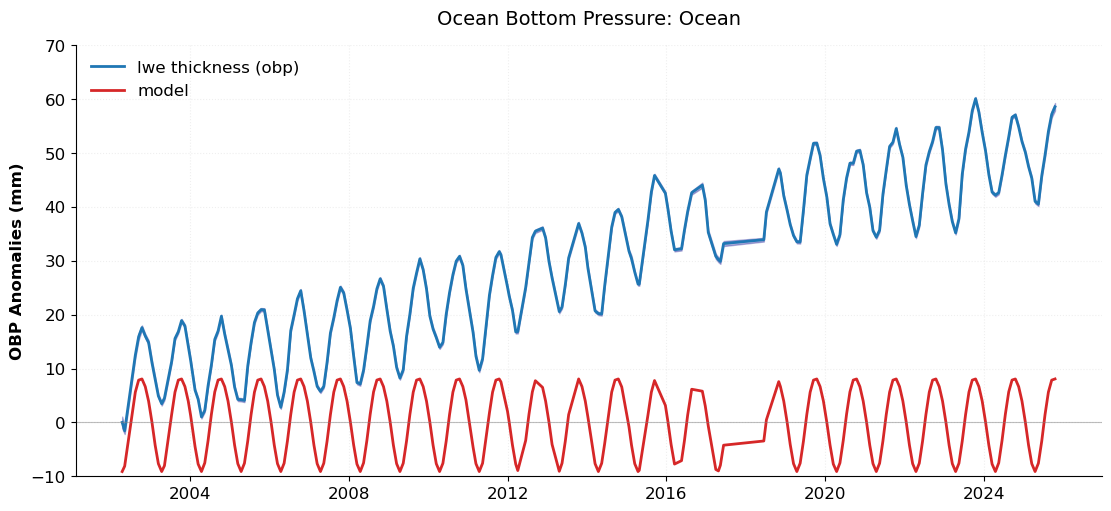

In [26]:
# Now only fit the seasonal cycle and remove it to get deseasoned estimate
rsd = regional_timeseries - get_model #residue
ocean_ds = rsd - rsd[0]#deseasoned

# plot monthly timeseries (#ref: https://unidata.github.io/python-training/workshop/Time_Series/basic-time-series-plotting/)
plt.rc('font', size=12)
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
# Specify how our lines should look
region_color='darkblue'
ax.plot(timesteps, regional_timeseries, color='tab:blue', label='lwe thickness (obp)',lw=2)
ax.plot(timesteps, get_model, color='tab:red', label='model',lw=2)

ax.fill_between(timesteps, lower_bound, upper_bound, alpha=0.3, edgecolor=region_color, facecolor=region_color)

ax.axhline(y=0.0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_ylabel('OBP Anomalies (mm)', fontweight='bold')
ax.set_title(plot_title_str, fontsize=14, pad=15)
ax.set_ylim([ymin, ymax])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, linestyle=':')
ax.legend(loc='best', frameon=False)

In [27]:
# Prepare the data and the header to be written into txt file
end_year = end_date_obj.year
end_month = end_date_obj.month

formatted_month = f"{end_month:02}"
formatted_year = str(end_year)
formatted_date = f"{formatted_month}/{formatted_year}"

lines_of_strings = header_text.header_data(formatted_date,mask_str,trend,slope_sig)
# Ensure vectors are the same length
assert len(timesteps_yearfrac) == len(bsn_sig) == len(regional_timeseries) == len(ocean_ds), "Vectors must be of the same length"

try:
    if (len(timesteps_yearfrac) == len(bsn_sig) == len(regional_timeseries)):
        # Combine the vectors into a tab-delimited string
        combined_vectors = np.column_stack((timesteps_yearfrac, regional_timeseries,bsn_sig,ocean_ds))
except Exception as e:
    print(f"An error occurred while combining vectors: {e}")

In [28]:
# Write the combined text and data to the file
with open(output_filename, 'w') as file:
    for line in lines_of_strings:
        file.write(line + "\n")
    # Write the vectors
    for i in range(len(timesteps_yearfrac)):
        file.write(f"{timesteps_yearfrac[i]:6.2f}   {regional_timeseries[i]:>5.2f}   {bsn_sig[i]:>5.2f}    {ocean_ds[i]:>5.2f}\n")

print(f"Data has been written to {output_filename}")

Data has been written to ocean_mass_200204_202510.txt
